In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2,3,4: For states
# 5,6: Ancillary qubits

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt, array
from qiskit.circuit.library import StatePreparation

def circuit_init():
    qc = QuantumCircuit(7)
    return qc
    
def PREP(qc):

    desired_vector = [
        1 / sqrt(3), 0, 0, 0, 0, 0, 0, 0,
        -1 / (8 * sqrt(3)), -1 / 8, -1 / 8, -sqrt(3) / 8,
        -1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, -3 / 8,
        -1 / (8 * sqrt(3)), 1 / 8, 1 / 8, -sqrt(3) / 8,
        1 / 8, -sqrt(3) / 8, -sqrt(3) / 8, 3 / 8,
        0, 0, 0, 0, 0, 0, 0, 0
    ]
    prep = StatePreparation(desired_vector)
    qc.append(prep,[4,3,2,1,0])
    return qc

In [3]:
def Ansatz(qc, wires, num_layers, params):

    for i in range(num_layers):
        qc.barrier()

        offset = 10 * i
        qc.rx(params[offset + 0], wires[0])
        qc.rz(params[offset + 1], wires[0])

        qc.rx(params[offset + 2], wires[1])
        qc.rz(params[offset + 3], wires[1])

        qc.rx(params[offset + 4], wires[2])
        qc.rz(params[offset + 5], wires[2])

        qc.rx(params[offset + 6], wires[3])
        qc.rz(params[offset + 7], wires[3])

        qc.rx(params[offset + 8], wires[4])
        qc.rz(params[offset + 9], wires[4])

        qc.cx(wires[0], wires[1])
        qc.cx(wires[1], wires[2])
        qc.cx(wires[2], wires[3])
        qc.cx(wires[3], wires[4])

    qc.measure_all()

    return qc

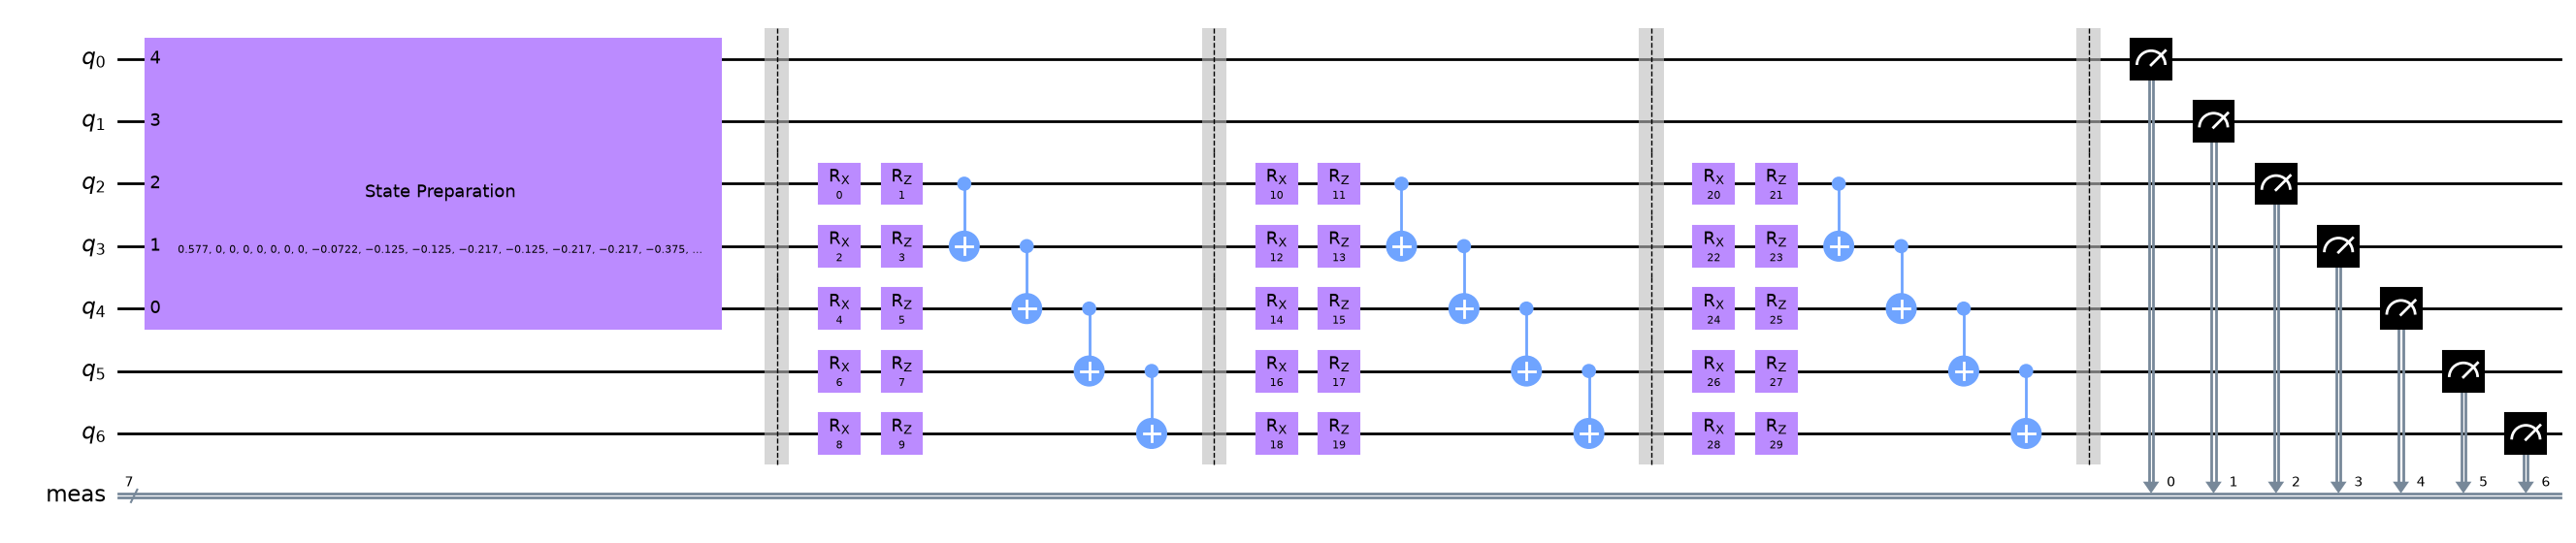

In [4]:
from numpy.random import rand
num_layers=3
num_params= 10*num_layers
params = list(range(num_params))
num_shots=10000

qc = circuit_init()
qc = PREP(qc)
Ansatz(qc, [2,3,4,5,6] , num_layers, params)

qc.draw(output='mpl', fold = False, style = 'clifford') 
#qc_reversed=qc.reverse_bits()
#qc_reversed.draw(output='mpl',style = 'clifford') 

In [5]:
# q_00: priori probability of psi_00
# p_00: Tr[M_00 psi_00]
# p_suc = q_00 p_00 + q_01 p_01 + q_10 p_10 = sum_i (tot_i/num_shots)(tar_i/tot_i) = 1/num_shots sum_i tar_i

In [6]:
# ============================================================
# AWS Braket / IQM Garnet setup
# ============================================================

from braket.aws import AwsDevice
from qiskit_braket_provider import BraketProvider
from qiskit import transpile
import numpy as np

GARNET_ARN = "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"

# Check device status. This does NOT submit a paid task.
garnet_device = AwsDevice(GARNET_ARN)

print("Device name   :", garnet_device.name)
print("Device status :", garnet_device.status)

try:
    qd = garnet_device.queue_depth()
    print("Quantum-task queue :", qd.quantum_tasks)
    print("Hybrid-job queue   :", qd.jobs)
except Exception as exc:
    print("Queue depth unavailable:", exc)

provider = BraketProvider()
garnet_backend = provider.get_backend("Garnet")

print("Qiskit-Braket backend:", garnet_backend)

HARDWARE_RUN = True

Device name   : Garnet
Device status : ONLINE
Quantum-task queue : {<QueueType.NORMAL: 'Normal'>: '0', <QueueType.PRIORITY: 'Priority'>: '0'}
Hybrid-job queue   : 0
Qiskit-Braket backend: BraketBackend[Garnet]


In [7]:
# ============================================================
# Fixed optimal parameters
# ============================================================
import numpy as np
num_layers = 3
num_params = 10 * num_layers

optimal_params = np.array([
-1.4018493450e+00,  2.9492174876e+00,  1.0922639818e-03,
 -1.6993675959e+00,  1.8790767860e-01, -5.2876097325e-02,
 -1.0673702703e-02,  1.5706522411e+00,  1.5748770911e+00,
  1.6102129051e+00, -4.8140116435e-01,  2.5851145096e+00,
  3.4710665799e-01,  8.4066550863e-01, -9.9098879799e-02,
  2.2017306804e+00,  4.3003562730e-03, -6.5986663930e-01,
  2.1000223571e-01,  1.5681659966e+00,  1.5252441009e+00,
  5.8015601442e-01,  1.6573172215e-02,  8.3509806177e-01,
  1.5041998340e+00,  5.5003893384e-01, -2.6915583910e-02,
 -2.9372064710e-02,  1.5796115058e+00,  3.9346379309e-01
], dtype=float)

assert len(optimal_params) == num_params

print("Number of layers     :", num_layers)
print("Number of parameters :", len(optimal_params))

Number of layers     : 3
Number of parameters : 30


In [8]:
# ============================================================
# Debug with AerSimulator
# ============================================================

from qiskit_aer import AerSimulator
from qiskit import transpile

debug_shots = 100000
debug_seed = 150

aersim = AerSimulator()


# ------------------------------------------------------------
# Construct circuit
# ------------------------------------------------------------

qc_debug = circuit_init()

PREP(qc_debug)

Ansatz(
    qc_debug,
    wires=[2, 3, 4, 5, 6],
    num_layers=num_layers,
    params=optimal_params
)

qc_debug = qc_debug.reverse_bits()


# ------------------------------------------------------------
# Transpile and run
# ------------------------------------------------------------

t_qc_debug = transpile(
    qc_debug,
    backend=aersim,
    optimization_level=3,
    seed_transpiler=debug_seed
)

job_debug = aersim.run(
    t_qc_debug,
    shots=debug_shots,
    seed_simulator=debug_seed
)

result_debug = job_debug.result()
counts_debug = result_debug.get_counts()


# ------------------------------------------------------------
# Existing target-count mapping
# ------------------------------------------------------------

tar_00 = 0
tar_01 = 0
tar_10 = 0

for outcome, count in counts_debug.items():

    if outcome[0:2] == "00":
        if outcome[5:7] == "00":
            tar_00 += count

    if outcome[0:2] == "01":
        if outcome[5:7] == "01":
            tar_01 += count

    if outcome[0:2] == "10":
        if outcome[5:7] == "10":
            tar_10 += count


p_suc_debug = (
    tar_00
    + tar_01
    + tar_10
) / debug_shots


print("\n=== AerSimulator debug result ===")
print("tar_00 :", tar_00)
print("tar_01 :", tar_01)
print("tar_10 :", tar_10)
print("Success probability :", p_suc_debug)


=== AerSimulator debug result ===
tar_00 : 30242
tar_01 : 29372
tar_10 : 30688
Success probability : 0.90302


In [9]:
# ============================================================
# IQM Garnet: one run with optimal parameters
# ============================================================

import time

num_shots = 10000
seed_transpiler = 150


# ------------------------------------------------------------
# Construct actual circuit
# ------------------------------------------------------------

qc = circuit_init()

PREP(qc)

Ansatz(
    qc,
    wires=[2, 3, 4, 5, 6],
    num_layers=num_layers,
    params=optimal_params
)

qc_reverse = qc.reverse_bits()


# ------------------------------------------------------------
# Transpile for IQM Garnet
# ------------------------------------------------------------

t_qc = transpile(
    qc_reverse,
    backend=garnet_backend,
    optimization_level=3,
    seed_transpiler=seed_transpiler
)


# ============================================================
# IQM Garnet transpiled resource report
# ============================================================

op_counts = dict(t_qc.count_ops())

one_q = 0
two_q = 0
multi_q = 0
measurements = 0

for item in t_qc.data:

    name = item.operation.name
    nq = len(item.qubits)

    if name == "measure":
        measurements += 1
    elif nq == 1:
        one_q += 1
    elif nq == 2:
        two_q += 1
    elif nq > 2:
        multi_q += 1


print("\n=== IQM Garnet transpiled resource report ===")
print(f"{'num_qubits':22s}: {t_qc.num_qubits}")
print(f"{'depth':22s}: {t_qc.depth()}")
print(f"{'size':22s}: {t_qc.size()}")
print(f"{'1q_gate_count':22s}: {one_q}")
print(f"{'2q_gate_count':22s}: {two_q}")
print(f"{'multiq_gate_count':22s}: {multi_q}")
print(f"{'measurement_count':22s}: {measurements}")
print(f"{'cz_count':22s}: {int(op_counts.get('cz', 0))}")
print(f"{'cx_count':22s}: {int(op_counts.get('cx', 0))}")
print(f"{'operation_counts':22s}: {op_counts}")


# ============================================================
# Submit ONE paid QPU task
# ============================================================

if HARDWARE_RUN:

    start_time = time.perf_counter()

    job = garnet_backend.run(
        t_qc,
        shots=num_shots,
        verbatim=True
    )

    print("\nBraket task ID:")
    print(job.job_id())

    print("\nWaiting for result...")

    result = job.result()

    end_time = time.perf_counter()

    print("Task wall time:", end_time - start_time, "s")


    # --------------------------------------------------------
    # Counts
    # --------------------------------------------------------

    counts = result.get_counts()

    print("\nCounts:")
    print(counts)


    # --------------------------------------------------------
    # Existing target-count mapping
    # --------------------------------------------------------

    tar_00 = 0
    tar_01 = 0
    tar_10 = 0

    for outcome, count in counts.items():

        if outcome[0:2] == "00":
            if outcome[5:7] == "00":
                tar_00 += count

        if outcome[0:2] == "01":
            if outcome[5:7] == "01":
                tar_01 += count

        if outcome[0:2] == "10":
            if outcome[5:7] == "10":
                tar_10 += count


    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / num_shots


    print("\n=== Garnet result ===")
    print("tar_00 :", tar_00)
    print("tar_01 :", tar_01)
    print("tar_10 :", tar_10)
    print("Success probability :", p_suc)


=== IQM Garnet transpiled resource report ===
num_qubits            : 20
depth                 : 139
size                  : 207
1q_gate_count         : 156
2q_gate_count         : 44
multiq_gate_count     : 4
measurement_count     : 7
cz_count              : 44
cx_count              : 0
operation_counts      : {'r': 156, 'cz': 44, 'measure': 7, 'barrier': 4}


/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Barrier is not included in the current Target and will be ignored.
  _translate_to_braket(
/Users/sungwonyun/anaconda3/lib/python3.11/site-packages/qiskit_braket_provider/providers/adapter.py:270: UserWarning: Device does not support global phase; global phase of 2.356194490192358 will not be included in Braket circuit
  _translate_to_braket(



Braket task ID:
arn:aws:braket:eu-north-1:082674088760:quantum-task/787796b3-c4f5-4936-ab0c-60eac036ed11

Waiting for result...
Task wall time: 15.530135790992063 s

Counts:
{'0001000': 73, '1010000': 282, '0101010': 139, '0110101': 1215, '1010010': 897, '0011000': 766, '1011010': 60, '1001101': 150, '0000000': 826, '0010101': 312, '1010101': 65, '0010000': 125, '0101101': 191, '0010110': 10, '0100111': 72, '1011111': 107, '0000111': 136, '1000111': 107, '1011001': 8, '0100000': 101, '1001010': 197, '0000001': 35, '0010111': 95, '0011111': 207, '1001111': 138, '0110000': 171, '1010111': 203, '1001000': 72, '1111000': 19, '1000001': 7, '1011011': 12, '0000010': 201, '0011011': 25, '1000000': 77, '0111000': 52, '0011101': 191, '0101000': 72, '1001011': 12, '0111110': 7, '0101111': 82, '0001010': 120, '1000010': 78, '0001111': 71, '0011010': 260, '1110010': 9, '0010011': 13, '0001101': 151, '1010001': 11, '0000101': 142, '1010011': 24, '0001110': 6, '0110111': 212, '1110111': 1, '0110100